# Autograd

自动求导的逻辑：

正向传播：

计算机从左向右计算，并把每个节点的中间结果存下来：

节点 $u$：计算 $b \times c = 3 \times 2 = \mathbf{6}$

节点 $v$：计算 $a + u = 5 + 6 = \mathbf{11}$

最终节点 $J$：计算 $3 \times v = 3 \times 11 = \mathbf{33}$

关键点：在算出 $33$ 的同时，显存里已经记住了 $u=6$ 和 $v=11$

![屏幕截图 2026-02-14 215558.png](<attachment:屏幕截图 2026-02-14 215558.png>)
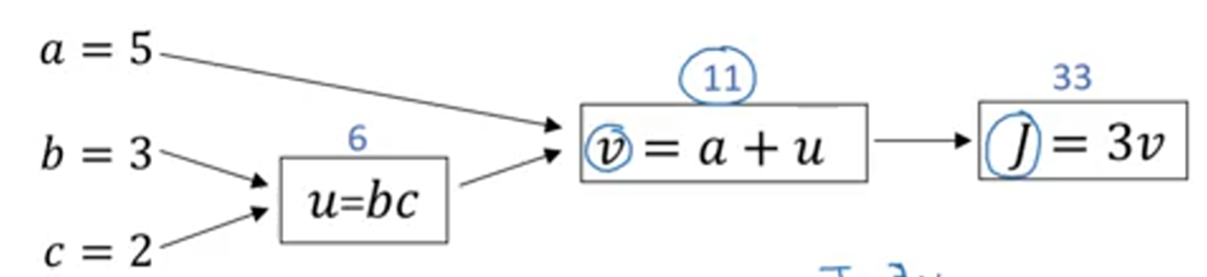

反向传播：

从最右边的 $J$ 开始向左“倒着推”，利用链式法则：

最后一层：$J$ 对 $v$ 的影响：局部导数：$\frac{\partial J}{\partial v} = 3$

中间层：$J$ 对 $a$ 和 $u$ 的影响：

$\frac{\partial J}{\partial a} = \frac{\partial J}{\partial v} \times \frac{\partial v}{\partial a} = 3 \times 1 = \mathbf{3}$

$\frac{\partial J}{\partial u} = \frac{\partial J}{\partial v} \times \frac{\partial v}{\partial u} = 3 \times 1 = \mathbf{3}$

最底层：$J$ 对 $b$ 和 $c$ 的影响：

$\frac{\partial J}{\partial b} = \frac{\partial J}{\partial u} \times \frac{\partial u}{\partial b} = 3 \times c = 3 \times 2 = \mathbf{6}$

$\frac{\partial J}{\partial c} = \frac{\partial J}{\partial u} \times \frac{\partial u}{\partial c} = 3 \times b = 3 \times 3 = \mathbf{9}$

In [5]:
import torch

# 1. 定义输入变量
a = torch.tensor(5.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(2.0, requires_grad=True)
print(a.grad)

# 2. 正向传播 
u = b * c      # 节点 u = 3 * 2 = 6
v = a + u      # 节点 v = 5 + 6 = 11
J = 3 * v      # 最终输出 J = 3 * 11 = 33

print(f"正向传播结果 J = {J.item()}")

# 3. 反向传播
J.backward() 

# 4. 查看结果
print("-" * 30)
print(f"a 的梯度 (dJ/da): {a.grad}")  
print(f"b 的梯度 (dJ/db): {b.grad}")  
print(f"c 的梯度 (dJ/dc): {c.grad}")  

None
正向传播结果 J = 33.0
------------------------------
a 的梯度 (dJ/da): 3.0
b 的梯度 (dJ/db): 6.0
c 的梯度 (dJ/dc): 9.0
